In [1]:
import os

import matplotlib.pyplot as plt
import polars as pl
from sklearn.metrics import root_mean_squared_error
from xgboost import XGBRegressor

plt.style.use("ggplot")

# XGBoost Boosting Model

Gradient-boosted trees trained on hand-crafted molecular descriptors with early stopping against a held-out tuning set.

In [2]:
df = pl.read_parquet("../data/processed/baseline_model_features.parquet")
df.head()

key,name,smiles,mpC,formula,C_count,H_count,O_count,N_count,S_count,F_count,Cl_count,Br_count,I_count,molecular_weight,branch_count,cycle_count,aromatic_ring_count,double_bond_count,triple_bond_count,carboxylic_acid_count,alcohol_count,carbonyl_count,prim_sec_amine_count,amide_count,hbd_count,hba_count,logp,tpsa,rotatable_bond_count,frac_csp3,stereocenters,bertz_ct,bridgehead_atoms,spiro_atoms,heterocycle_count,ring_atom_ratio,split
i64,str,str,f64,str,i32,i32,i32,i32,i32,i32,i32,i32,i32,f64,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,f64,f64,i32,f64,i32,f64,i32,i32,i32,f64,str
27956,"""cyclobutylmethane""","""C1(CCC1)C""",-161.51,"""C5H10""",5,10,0,0,0,0,0,0,0,70.135,0,1,0,0,0,0,0,0,0,0,0,0,1.8064,0.0,0,1.0,0,27.01955,0,0,0,0.8,"""train"""
16005,"""Nitrogen oxide""","""[O-][N+]#N""",-90.8,"""N2O""",0,0,1,2,0,0,0,0,0,44.013,0,0,0,0,1,0,0,0,0,0,0,2,0.33728,51.21,0,0.0,0,24.264663,0,0,0,0.0,"""train"""
16127,"""Sulfuryl difluoride""","""FS(F)(=O)=O""",-135.8,"""F2O2S""",0,0,2,0,1,2,0,0,0,102.061,1,0,0,2,0,0,0,0,0,0,0,2,0.1702,34.14,0,0.0,0,90.816358,0,0,0,0.0,"""train"""
17138,"""disopyramide""","""CC(C)N(CCC(c1ccccn1)(c2ccccc2)…",94.8,"""C21H29N3O""",21,29,1,3,0,0,0,0,0,339.483,5,2,2,1,0,0,0,1,0,1,1,3,3.3619,59.22,8,0.428571,1,620.555222,0,0,1,0.48,"""train"""
15628,"""Bromine""","""BrBr""",-7.2,"""Br2""",0,0,0,0,0,0,0,2,0,159.808,0,0,0,0,0,0,0,0,0,0,0,0,1.6912,0.0,0,0.0,0,0.0,0,0,0,0.0,"""test"""


In [3]:
FEATURE_COLS = [c for c in df.columns if c not in ("key", "name", "smiles", "mpC", "formula", "split")]

train_df = df.filter(pl.col("split") == "train")
tune_df  = df.filter(pl.col("split") == "tune")
test_df  = df.filter(pl.col("split") == "test")

X_train = train_df.select(FEATURE_COLS)
X_tune  = tune_df.select(FEATURE_COLS)
X_test  = test_df.select(FEATURE_COLS)
y_train = train_df.select(["key", "mpC"])
y_tune  = tune_df.select(["key", "mpC"])
y_test  = test_df.select(["key", "mpC"])

print(f"Train: {X_train.height}  Tune: {X_tune.height}  Test: {X_test.height}")

Train: 2116  Tune: 299  Test: 609


In [4]:
model = XGBRegressor(
    n_estimators=10_000,
    learning_rate=0.005,
    max_depth=3,
    subsample=0.5,
    early_stopping_rounds=20,
    random_state=97,
)

In [5]:
model.fit(
    X_train, y_train.select(pl.col("mpC")),
    eval_set=[(X_tune, y_tune.select(pl.col("mpC")))],
    verbose=100
)

[0]	validation_0-rmse:97.94308
[100]	validation_0-rmse:75.21897
[200]	validation_0-rmse:62.74599
[300]	validation_0-rmse:56.09222
[400]	validation_0-rmse:52.28370
[500]	validation_0-rmse:49.96654
[600]	validation_0-rmse:48.47992
[700]	validation_0-rmse:47.42725
[800]	validation_0-rmse:46.58903
[900]	validation_0-rmse:45.91394
[1000]	validation_0-rmse:45.41777
[1100]	validation_0-rmse:44.95338
[1200]	validation_0-rmse:44.58206
[1300]	validation_0-rmse:44.32152
[1400]	validation_0-rmse:44.04239
[1500]	validation_0-rmse:43.80867
[1600]	validation_0-rmse:43.55671
[1700]	validation_0-rmse:43.34439
[1800]	validation_0-rmse:43.24236
[1900]	validation_0-rmse:43.10262
[2000]	validation_0-rmse:42.96898
[2100]	validation_0-rmse:42.83701
[2200]	validation_0-rmse:42.70837
[2300]	validation_0-rmse:42.57986
[2400]	validation_0-rmse:42.48658
[2500]	validation_0-rmse:42.40469
[2600]	validation_0-rmse:42.30373
[2700]	validation_0-rmse:42.24537
[2713]	validation_0-rmse:42.25040


,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",20
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


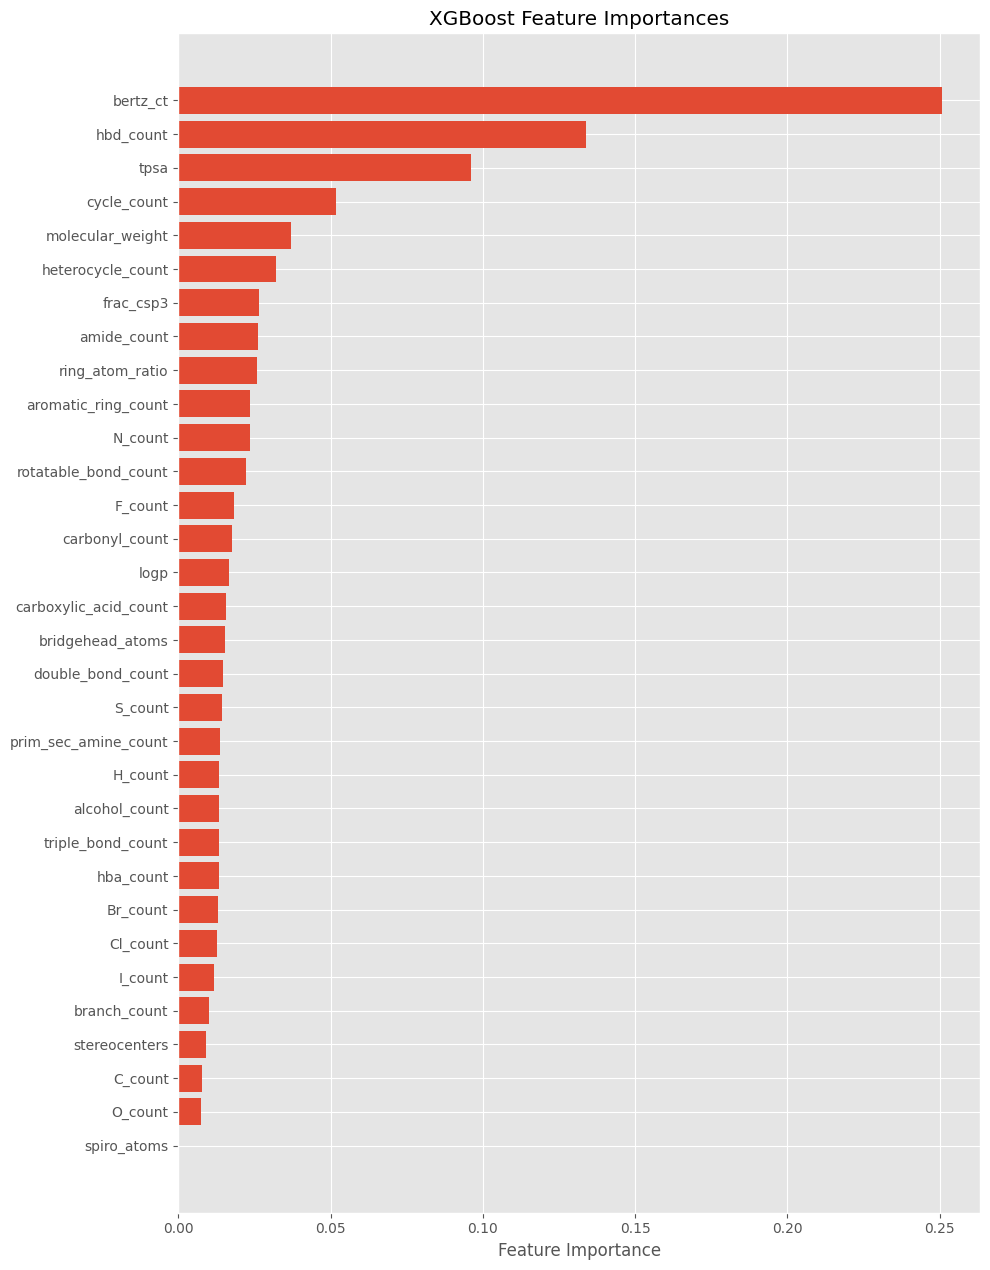

In [6]:
feature_names = X_train.columns
importances = model.feature_importances_

sorted_idx = importances.argsort()

plt.figure(figsize=(10, len(feature_names) * 0.4))
plt.barh([feature_names[i] for i in sorted_idx], importances[sorted_idx])
plt.xlabel("Feature Importance")
plt.title("XGBoost Feature Importances")
plt.tight_layout()
plt.savefig("../img/boosting_feature_imp.png")
plt.show()

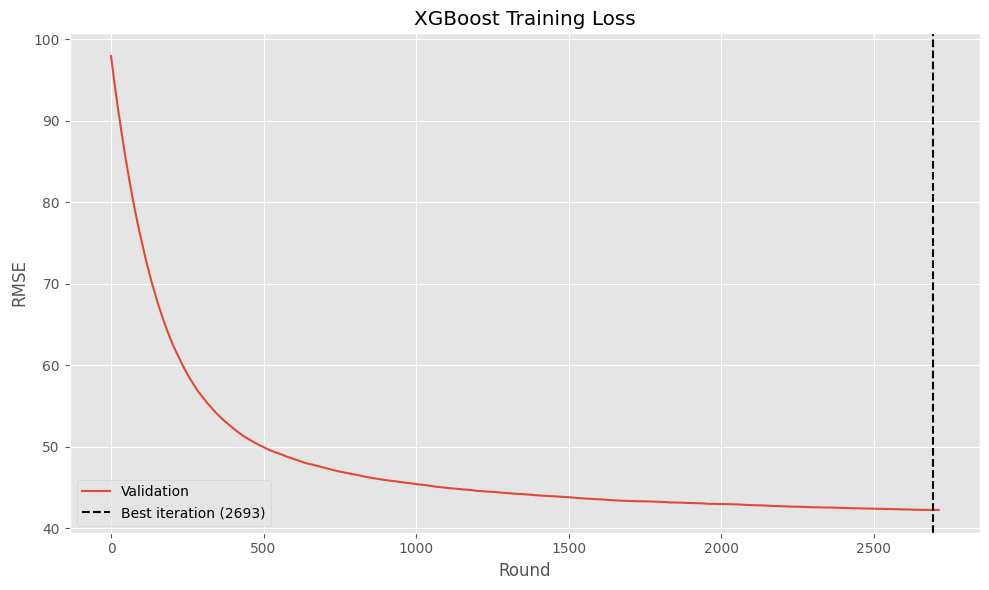

In [7]:
results = model.evals_result()

plt.figure(figsize=(10, 6))
plt.plot(results["validation_0"]["rmse"], label="Validation")
plt.axvline(model.best_iteration, color="k", linestyle="--", label=f"Best iteration ({model.best_iteration})")
plt.xlabel("Round")
plt.ylabel("RMSE")
plt.title("XGBoost Training Loss")
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
y_pred = model.predict(X_test)
root_mean_squared_error(y_test["mpC"], y_pred)

39.67369064066058

In [9]:
y_test = y_test.with_columns(y_pred=y_pred)
y_test = y_test.with_columns(errors = y_test["y_pred"] - y_test["mpC"])
y_test.head()

key,mpC,y_pred,errors
i64,f64,f32,f64
15628,-7.2,-61.068439,-53.868439
16624,239.75,196.181824,-43.568176
7376,-93.0,-66.078293,26.921707
13717,-67.0,-37.83765,29.16235
13629,-103.0,-93.627686,9.372314


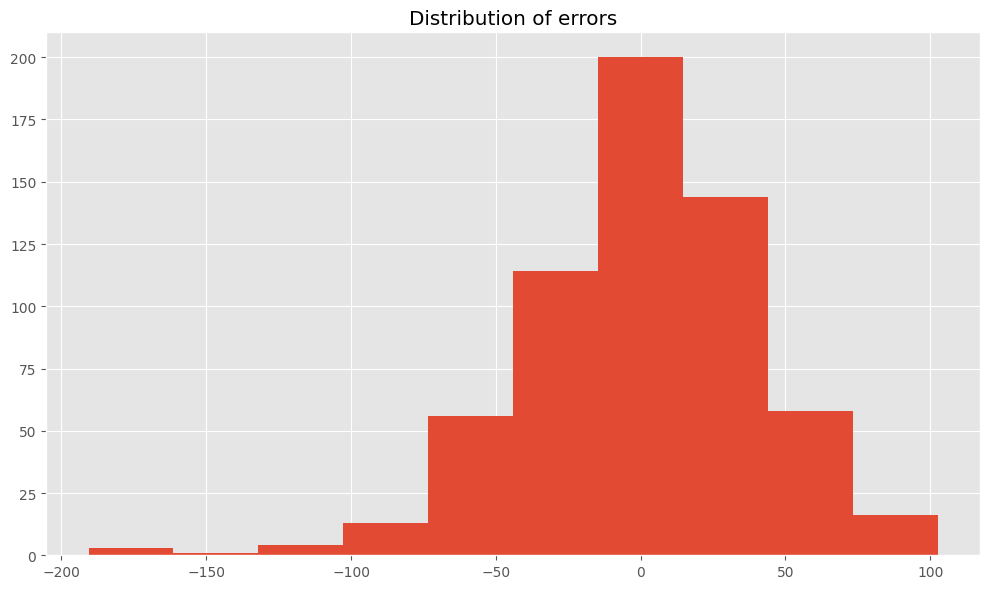

In [10]:
plt.figure(figsize=(10, 6))
plt.hist(y_test["errors"])
plt.title("Distribution of errors")
plt.tight_layout()
plt.show()

In [11]:
os.makedirs("../data/predictions", exist_ok=True)
(
    y_test
    .rename({"mpC": "y_true"})
    .select(["key", "y_true", "y_pred"])
    .write_parquet("../data/predictions/xgb_predictions.parquet")
)
print("Saved XGBoost test predictions.")

Saved XGBoost test predictions.
